In [ ]:
# Usage Notes
# This notebook only provides spectra for combined model of all spots so that it be computation effective for certain experiments.
# - Update `SPICE_SRC_PATH` and `ZARR_PATH` in the first code cell before running the notebook.
# - All user-configurable settings are collected in **Cell 9**. Modify parameters there only.
# - Available stellar parameters and their valid grid ranges are listed in **Cell 5**. Ensure perturbations remain within grid limits.
# - Running the notebook with a new parameter configuration creates a new output file automatically.
# - Re-running with the same configuration will overwrite the previous output file(s).
# - Plot labels, colorbars, filenames, and animations update automatically based on the selected parameter and wavelength range.

In [29]:
import jax
import sys

for mod in list(sys.modules):
    if mod.startswith("spice"):
        del sys.modules[mod]

SPICE_SRC_PATH = r"C:\Users\ASUS\Downloads\spice-main\spice-main\src"                         # ← replace with your path

ZARR_PATH      = r'C:\Users\ASUS\Downloads\fe_nlte_regular.zarr (1)\fe_nlte_regular.zarr'     # ← replace with your path


sys.path.insert(0, SPICE_SRC_PATH)

from spice.spectrum.lazy_zarr_interpolator import IntensityLazyZarrInterpolator
from spice.models import IcosphereModel
from spice.models.mesh_transform import add_rotation, evaluate_rotation
from spice.models.spots import add_spots, add_spot
from spice.plots import plot_3D
from spice.spectrum import simulate_observed_flux
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cmasher as cmr
from spice.spectrum.aemu_spectrum_emulator import IntensityPretrainedAemuSpectrumEmulator
import astro_emulators_toolkit as aemu

In [30]:
from spice.spectrum.lazy_zarr_interpolator import IntensityLazyZarrInterpolator
print(IntensityLazyZarrInterpolator)

<class 'spice.spectrum.lazy_zarr_interpolator.IntensityLazyZarrInterpolator'>


# Spotted star from Kochukhov (2017)

In [31]:
import zarr

g = zarr.open_group(ZARR_PATH
    
)

print(g.tree())

/
├── continuum (203070, 2001) float32
├── flux (203070, 2001) float32
├── global_index (203070,) int64
├── model_id (203070,) uint64
├── param_names (11,) <U32
├── params (203070, 11) float32
├── physics_hash (1,) <U72
├── provenance
│   ├── atmosphere_manifest.json (1,) StringDType()
│   ├── canonical_config.yaml (1,) StringDType()
│   ├── environment.txt (1,) StringDType()
│   ├── linelist_manifest.json (1,) StringDType()
│   ├── software_manifest.json (1,) StringDType()
│   └── synthesis_config.yaml (1,) StringDType()
├── schema_version (1,) <U16
└── wavelength (2001,) float32



In [32]:
line_interp = IntensityLazyZarrInterpolator(
    ZARR_PATH,
    params=['teff', 'logg', '[Fe/H]', 'vmicro', '[a/Fe]', '[C/Fe]', '[N/Fe]', '[O/Fe]', '[r/Fe]', '[s/Fe]', 'mu'],
    sparse=True
)

[spice] Building sparse grid index...
[spice] Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 0.5 s


In [33]:
# parameters that can be varied with their bounds

for n, mn, mx in zip(
    line_interp._stellar_parameter_names,
    line_interp.min_stellar_parameters,
    line_interp.max_stellar_parameters
):
    print(f"{n:10s} {mn:8.3f} {mx:8.3f}")

teff       3800.000 8550.000
logg          0.000    5.000
[Fe/H]       -4.500    0.500
vmicro        0.000    5.000
[a/Fe]        0.000    0.000
[C/Fe]        0.000    0.000
[N/Fe]        0.000    0.000
[O/Fe]        0.000    0.000
[r/Fe]        0.000    0.000
[s/Fe]        0.000    0.000


In [34]:
import sys
print(sys.executable)

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\python.exe


In [35]:
m = IcosphereModel.construct(10000, 1.9, 1.5,
                             line_interp.to_parameters({'teff':8000, 'logg':4.0, '[Fe/H]':-1.0, 'vmicro':1.0}),
                             line_interp.stellar_parameter_names, override_log_g=False)


[spice] IcosphereModel constructed in 1.3 s


In [36]:
incl = 60.
# Calculate v_e from v_e*sin(incl) = 40 km/s
v_e_sin_i = 40.  # km/s
incl_rad = np.deg2rad(incl)
v_e = v_e_sin_i / np.sin(incl_rad)
print(f"v_e = {v_e:.2f} km/s (with v_e*sin(i) = {v_e_sin_i} km/s at inclination {incl}°)")

v_e = 46.19 km/s (with v_e*sin(i) = 40.0 km/s at inclination 60.0°)


In [ ]:
#        Only edit this cell to run new experiments

SPOT_LATS = [10]
SPOT_LONS = [0]
SPOT_RADIUS = 17.61
#safety check
assert len(SPOT_LATS) == len(SPOT_LONS), \
    "SPOT_LATS and SPOT_LONS must have the same length."

N_SPOTS = len(SPOT_LATS)

DELTA = 0                           # Parameter perturbation
PARAM_INDEX = 2                       # 0=Teff, 1=logg, 2=[Fe/H], 3=vmicro
SMOOTHNESS = 0.5                      # Spot edge smoothing

WL_START = 5000                       # Å
WL_END = 5020                         # Å
N_WL = 200                            # Number of wavelength samples

N_PHASES = 25                         # Number of rotational phases



In [38]:
PARAM_LABELS = {
    0: "Teff (K)",
    1: "log g",
    2: "[Fe/H]",
    3: "vmicro",
    4: "[α/Fe]",
    5: "[C/Fe]",
    6: "[N/Fe]",
    7: "[O/Fe]",
    8: "[r/Fe]",
    9: "[s/Fe]",
    10: "μ"
}

In [ ]:
from spice.models.mesh_view import get_mesh_view
from spice.models.utils import (
    inclination_to_los_axis,
    lat_to_theta,
    lon_to_phi,
    velocity_to_period,
)

period_seconds = velocity_to_period(v_e, m.radius)
timestamps = jnp.linspace(0, period_seconds, N_PHASES)

# Convert inclination to LOS vector
mt = get_mesh_view(add_rotation(m, v_e),
                   los_vector=inclination_to_los_axis(incl))



ms = add_spots(
    mt,
    spot_center_thetas=jnp.array([lat_to_theta(lat) for lat in SPOT_LATS]),
    spot_center_phis=jnp.array([lon_to_phi(lon) for lon in SPOT_LONS]),
    spot_radii=jnp.array([SPOT_RADIUS] * N_SPOTS),
    parameter_deltas=jnp.array([DELTA] * N_SPOTS),
    parameter_indices=jnp.array([PARAM_INDEX] * N_SPOTS),
    smoothness=jnp.array([SMOOTHNESS] * N_SPOTS),
)



In [40]:
from tqdm import tqdm

In [41]:

mts = [evaluate_rotation(ms, t) for t in tqdm(timestamps)]


print(f"Computed rotations for  spot models.")

100%|██████████| 25/25 [00:00<00:00, 80.62it/s]

Computed rotations for  spot models.


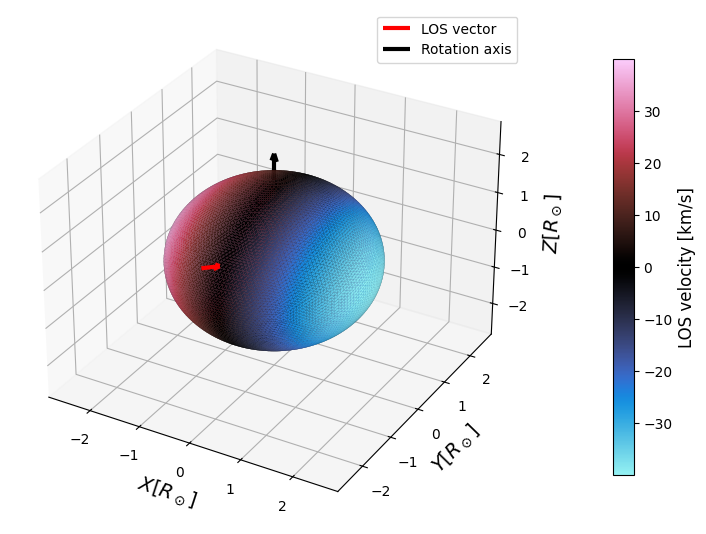

In [42]:
fig, _ = plot_3D(mts[0], 'los_velocities');

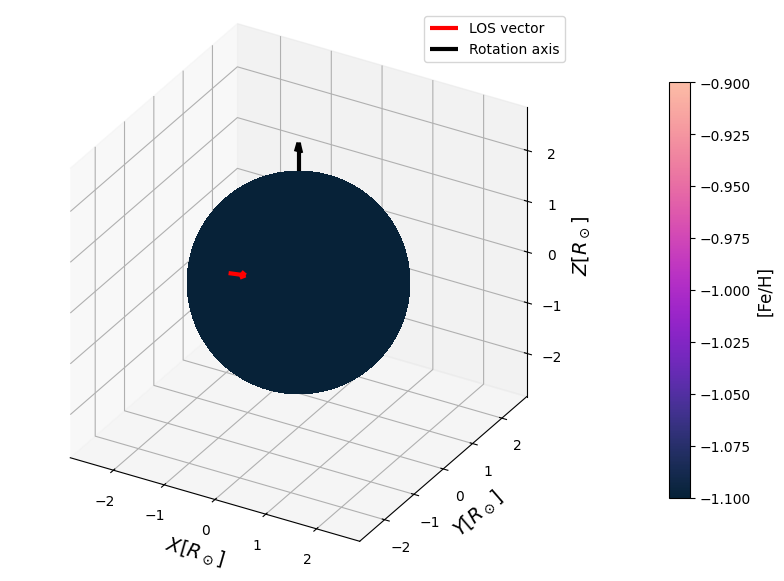

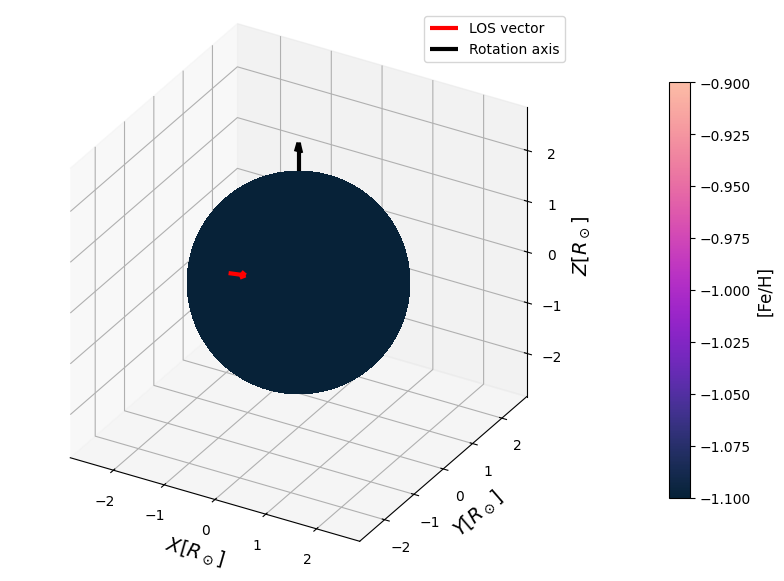

In [43]:
import matplotlib as mpl
from mpl_toolkits.mplot3d import art3d
from spice.plots.plot_mesh import (
    DEFAULT_CMAP,
    _mesh_center,
    _set_axes_centered,
    _single_mesh_arrow_vectors,
)

mesh = mts[5]
fe_h = np.asarray(mesh.parameters[:, PARAM_INDEX])
cmap = DEFAULT_CMAP
vmin, vmax = fe_h.min(), fe_h.max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig_fe = plt.figure(figsize=(10, 12))
ax_fe = fig_fe.add_subplot(projection="3d")
ax_fe.set_proj_type("ortho")

face_colors = mpl.colormaps[cmap](norm(fe_h))
ax_fe.add_collection(art3d.Poly3DCollection(
    mesh.mesh_elements,
    facecolors=face_colors,
    edgecolor="none",
    linewidths=0,
    antialiased=False,
))

center = _mesh_center(mesh)
axes_lim = 1.5 * float(mesh.radius)
_set_axes_centered(ax_fe, center, axes_lim)
ax_fe.set_xlabel("$X [R_\\odot]$", fontsize=14)
ax_fe.set_ylabel("$Y [R_\\odot]$", fontsize=14)
ax_fe.set_zlabel("$Z [R_\\odot]$", fontsize=14)
ax_fe.set_box_aspect((1, 1, 1))

los_start, los_vec, rotation_start, rotation_vec = _single_mesh_arrow_vectors(mesh)
ax_fe.quiver(*los_start, *los_vec, color="red", linewidth=3.0, label="LOS vector")
ax_fe.quiver(*rotation_start, *rotation_vec, color="black", linewidth=3.0, label="Rotation axis")
ax_fe.legend()

ax_fe.view_init(elev=30, azim=-60)

mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array([])
cbar = fig_fe.colorbar(mappable, shrink=0.45, pad=0.125, ax=ax_fe)
cbar.set_label(PARAM_LABELS[PARAM_INDEX], fontsize=12)
fig_fe

In [48]:
# wavelength grid

vws = jnp.linspace(WL_START, WL_END, N_WL)

# Combined spectrum (all spots together)
spec = []

for mt_rot in tqdm(mts, desc="Combined model"):
    spectrum = simulate_observed_flux(
        line_interp.intensity,
        mt_rot,
        jnp.log10(vws)
    )
    spec.append(spectrum)


#Diagonostic check

spec_flux = np.stack([np.asarray(s[:, 0]) for s in spec])

pairwise = [
    np.max(np.abs(spec_flux[i] - spec_flux[j]))
    for i in range(len(spec))
    for j in range(i + 1, len(spec))
]

print(f"Maximum pairwise flux difference across phases: {max(pairwise):.6e}")

print(
    "LOS velocity std (phase 0 / mid / last):",
    [
        float(np.std(np.asarray(mts[k].los_velocities)))
        for k in (0, len(mts) // 2, -1)
    ],
)

Combined model: 100%|██████████| 25/25 [03:54<00:00,  9.37s/it]

Maximum pairwise flux difference across phases: 2.950973e-13
LOS velocity std (phase 0 / mid / last): [23.08987808227539, 23.08987808227539, 23.08987808227539]


In [56]:
# save the spectra as text  files for each phase 


from pathlib import Path
import numpy as np

output_dir = Path("combined_spectra_morphology")
output_dir.mkdir(exist_ok=True)


lat_string = "_".join(f"{lat:+.0f}" for lat in SPOT_LATS)
lon_string = "_".join(f"{lon:.0f}" for lon in SPOT_LONS)

config_name = f"laat_{lat_string}_lon_{lon_string}"

for phase, spectrum in enumerate(spec):

    flux = spectrum[:,0] / spectrum[:,1] 

    data = np.column_stack((vws, flux))

    filename = output_dir / (
        f"{config_name}_phase_{phase:02d}.txt"
    )

    np.savetxt(
        filename,
        data,
        fmt="%.8f",
        header="Wavelength(A)  Normalized_Flux",
        comments=""
    )

print(f"Saved {len(spec)} spectra to '{output_dir}'.")

Saved 25 spectra to 'combined_spectra_morphology'.


In [53]:
ratio = spectrum[:,0]/spectrum[:,1]
print(ratio.min(), ratio.max())

0.88957363 0.99960226


In [22]:
spec = np.array(spec)

In [23]:
import pickle

# Save all spectra arrays to a pickle file
spectra_data = {
    'wavelengths': vws,
    'spec': spec,
    'timestamps': timestamps,

    # Store experiment configuration
    'spot_lats': SPOT_LATS,
    'spot_lons': SPOT_LONS,
    'spot_radius': SPOT_RADIUS,
    'delta': DELTA,
    'parameter_index': PARAM_INDEX,
    'smoothness': SMOOTHNESS,
    'n_spots': N_SPOTS,
    'n_phases': N_PHASES,
}

with open('kochukhov2017_spectra.pkl', 'wb') as f:
    pickle.dump(spectra_data, f)

print(f"Saved {N_SPOTS} spot models with {N_PHASES} rotational phases.")
print("Spectra saved to kochukhov2017_spectra.pkl")

Saved 1 spot models with 25 rotational phases.
Spectra saved to kochukhov2017_spectra.pkl


In [24]:
import pickle

with open("kochukhov2017_spectra.pkl", "rb") as f:
    loaded_spectra = pickle.load(f)

vws = loaded_spectra["wavelengths"]
spec = loaded_spectra["spec"]

timestamps = loaded_spectra["timestamps"]

print(f"Loaded 5 individual spot models.")

Loaded 5 individual spot models.


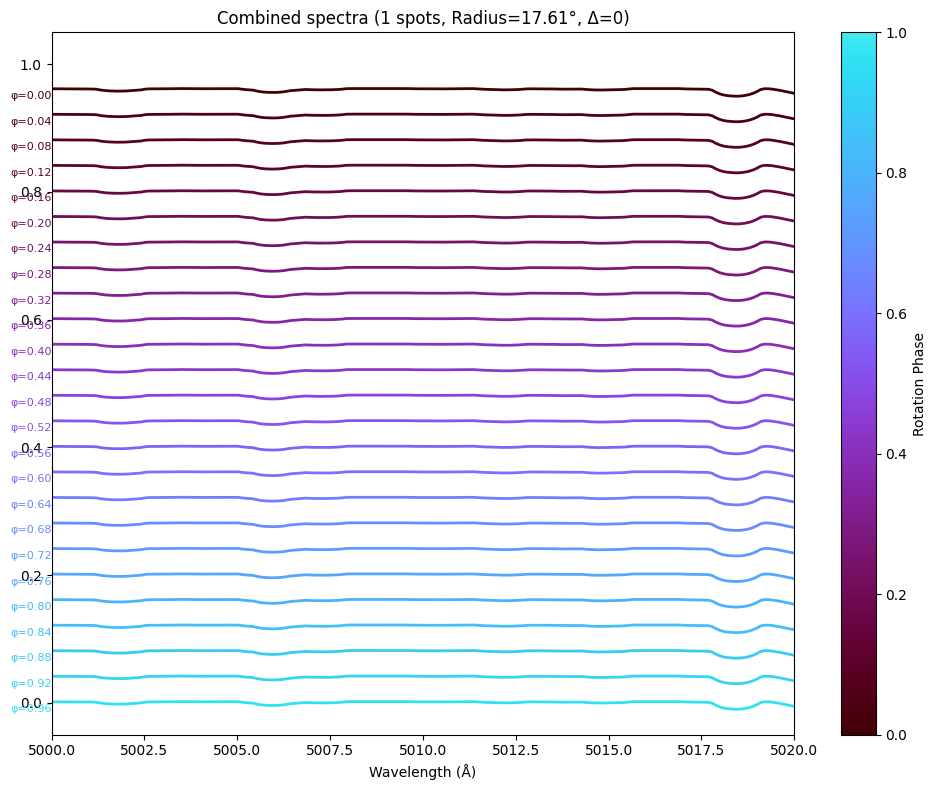

In [54]:
fig, ax = plt.subplots(figsize=(10, 8))

cmap = cmr.gem
colors = [cmap(i / len(spec)) for i in range(len(spec))]

n = len(spec)
row_height = 1.0 / n
y0 = 0.95

for i, spectrum in enumerate(spec):

    baseline = y0 - i * row_height

    flux = spectrum[:,0] / spectrum[:,1]

    scaled_flux = baseline + (
        (flux - flux.min()) /
        (flux.max() - flux.min() + 1e-8)
    ) * (0.3 * row_height)

    ax.plot(
        vws,
        scaled_flux,
        color=colors[i],
        linewidth=2
    )

    ax.text(
        WL_START,
        baseline,
        f"φ={i/n:.2f}",
        fontsize=8,
        ha="right",
        va="center",
        color=colors[i]
    )

ax.set_xlim(WL_START, WL_END)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Wavelength (Å)")
ax.set_title(
    f"Combined spectra ({N_SPOTS} spots, Radius={SPOT_RADIUS}°, Δ={DELTA})"
)

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=0, vmax=1)
)
sm.set_array([])

plt.colorbar(sm, ax=ax, label="Rotation Phase")

plt.tight_layout()
plt.show()

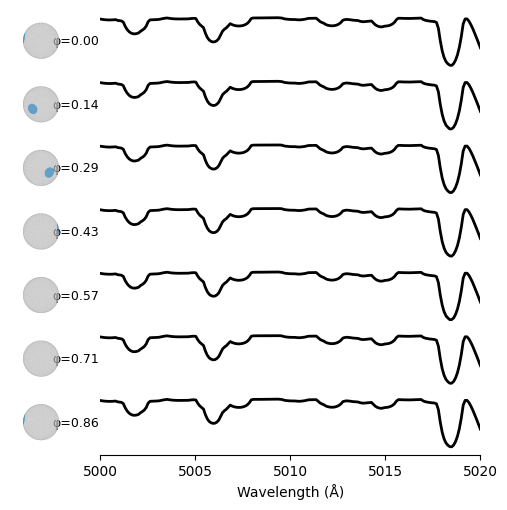

In [ ]:
# Row-per-phase figure: combined spectrum + 3D mesh inset for each phase

import matplotlib as mpl
from mpl_toolkits.mplot3d import art3d
from spice.plots.plot_mesh import _mesh_center, _set_axes_centered
from spice.models.spots import generate_spherical_spot

fig, ax = plt.subplots(figsize=(5,5))
ax.axis("off")

fig.subplots_adjust(left=0.22, right=0.98, top=0.95, bottom=0.06)

lim_start = WL_START
lim_end = WL_END

stride = 4

spec_to_plot = spec[::stride]
mts_to_plot = mts[::stride]
n = len(spec_to_plot)


all_curves = np.asarray([
    s[:,0] / s[:,1]
    for s in spec_to_plot
])

g_min = all_curves.min()
g_max = all_curves.max()
g_range = g_max - g_min + 1e-12

row_height = 1.0 / n
prof_scale = 0.75 * row_height
y0 = 1.0 - row_height/2

def to_row(flux, baseline):
    return baseline + (flux-g_min)*(prof_scale/g_range) - prof_scale/2



for i in range(n):

    baseline = y0 - i*row_height
    flux = spectrum[:,0] / spectrum[:,1]
    flux = spec_to_plot[i][:,0] / spec_to_plot[i][:,1]

    ax.plot(
        vws,
        to_row(flux, baseline),
        color="black",
        linewidth=2
    )

    phase = i/n

    ax.text(
        lim_start-0.05,
        baseline,
        f"φ={phase:.2f}",
        va="center",
        ha="right",
        fontsize=9
    )

ax.set_xlim(lim_start, lim_end)
ax.set_ylim(0,1)

ax_x = ax.twiny()

ax_x.set_xlim(lim_start, lim_end)

ax_x.xaxis.set_ticks_position("bottom")
ax_x.xaxis.set_label_position("bottom")

ax_x.spines["top"].set_visible(False)
ax_x.spines["left"].set_visible(False)
ax_x.spines["right"].set_visible(False)

ax_x.set_yticks([])

ax_x.set_xticks(np.linspace(WL_START, WL_END,5))
ax_x.set_xlabel("Wavelength (Å)")


cmap = plt.get_cmap("tab20")
spot_colors = [cmap(i/max(N_SPOTS-1,1)) for i in range(N_SPOTS)]

spot_contribs = np.stack([
    np.asarray(
        generate_spherical_spot(
            ms.d_centers,
            ms.radius,
            lat_to_theta(lat),
            lon_to_phi(lon),
            SPOT_RADIUS,
            1.0,
            0.5,
        )
    ) 
    for lat,lon in zip(SPOT_LATS,SPOT_LONS)
],axis=1)

best_spot = np.argmax(spot_contribs,axis=1)

best_contrib = np.take_along_axis(
    spot_contribs,
    best_spot[:,None],
    axis=1
).squeeze()

unspotted = best_contrib < 0.5

spot_rgba = np.array([mpl.colors.to_rgba(c) for c in spot_colors])

base = np.array(mpl.colors.to_rgba("0.75"))

face_colors = spot_rgba[best_spot]
face_colors[unspotted] = base


def los_view(mesh):

    los = np.array(mesh.los_vector)

    los /= np.linalg.norm(los)

    elev = np.degrees(np.arcsin(los[2]))
    azim = np.degrees(np.arctan2(los[1],los[0]))

    return elev,azim



ax_pos = ax.get_position()

inset_h = 0.95*row_height*ax_pos.height
inset_w = inset_h*fig.get_figheight()/fig.get_figwidth()

inset_right = ax_pos.x0-0.06
inset_left = max(0.005,inset_right-inset_w)

for i,mesh in enumerate(mts_to_plot):

    baseline = y0-i*row_height

    fig_y = ax_pos.y0 + baseline*ax_pos.height

    iax = fig.add_axes(
        [inset_left,
         fig_y-inset_h/2,
         inset_w,
         inset_h],
        projection="3d"
    )

    iax.set_axis_off()

    iax.set_proj_type("ortho")

    iax.patch.set_alpha(0)

    visible = np.asarray(mesh.mus)>0

    cols = face_colors.copy()
    cols[~visible] = (0,0,0,0)

    poly = art3d.Poly3DCollection(
        mesh.mesh_elements,
        facecolors=cols,
        edgecolor="none",
        linewidths=0
    )

    iax.add_collection(poly)

    center = _mesh_center(mesh)

    _set_axes_centered(
        iax,
        center,
        float(mesh.radius)
    )

    iax.set_box_aspect((1,1,1))

    elev,azim = los_view(mesh)

    iax.view_init(elev=elev,azim=azim)

plt.show()

TODO: color spots

In [57]:
# Save the figure as PDF
fig.savefig(f'kochukov2017_spectra_comparison_{SPOT_LATS}_{SPOT_LONS}_nlte.pdf', bbox_inches='tight', dpi=300)
print(f"Figure saved to kochukov2017_spectra_comparison_{PARAM_INDEX}_{DELTA}_nlte.pdf")

Figure saved to kochukov2017_spectra_comparison_2_0_nlte.pdf


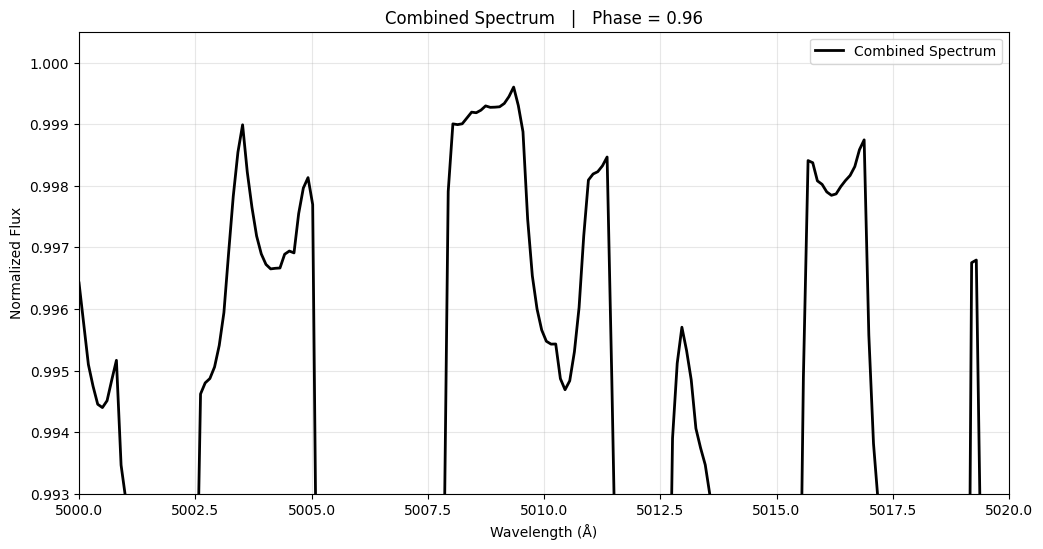

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


fig, ax = plt.subplots(figsize=(12, 6))

line, = ax.plot(
    [],
    [],
    color="black",
    linewidth=2,
    label="Combined Spectrum"
)

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Normalized Flux")
ax.set_xlim(WL_START, WL_END)
ax.set_ylim(0.993, 1.0005)

ax.grid(alpha=0.3)
ax.legend()



def init():
    line.set_data([], [])
    ax.set_title("Spectral Evolution - Phase: 0.00")
    return (line,)



def animate(frame):

    flux = spec[frame][:,0] / spec[frame][:,1]

    line.set_data(vws, flux)

    phase = frame / len(spec)

    ax.set_title(
        f"Combined Spectrum   |   Phase = {phase:.2f}"
    )

    return (line,)



anim = FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=len(spec),
    interval=200,
    blit=True,
    repeat=True,
)

HTML(anim.to_jshtml())

In [ ]:
# Save animation to file
anim.save(f'spectral_{SPOT_LATS}_{SPOT_LONS}_evolution.gif', writer='pillow', fps=5, dpi=100)
print(f"Animation saved to spectral_{SPOT_LATS}_{SPOT_LONS}_evolution.gif")

Animation saved to spectral_[0]_[0]_evolution.gif


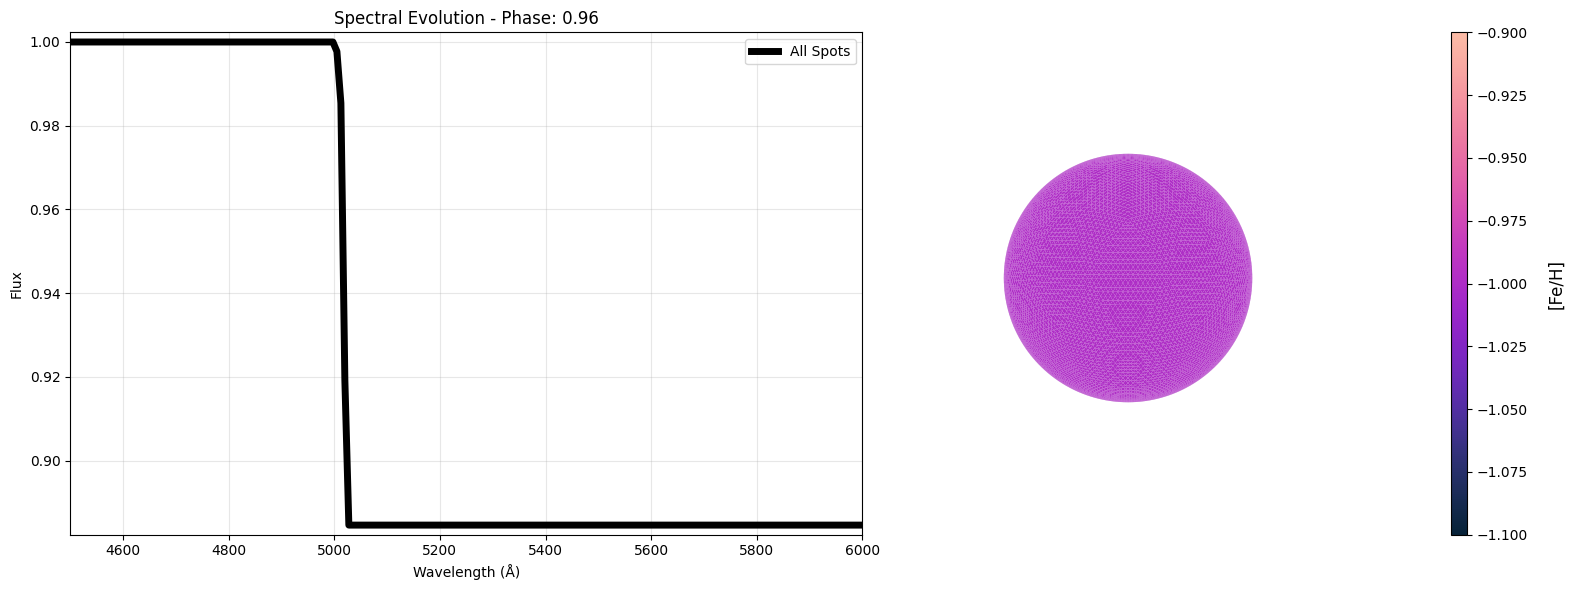

In [ ]:
from spice.plots.plot_mesh import *
import numpy as np

def _evaluate_to_be_mapped_property(mesh,
                                    property = DEFAULT_PROPERTY,
                                    property_label = None):
    """
    Evaluate the property to be mapped in visualization.
    (Implementation unchanged)
    """
    if isinstance(property, str):
        if property in DEFAULT_PLOT_PROPERTY_LABELS:
            to_be_mapped = getattr(mesh, property)
            if property_label is None:
                property_label = DEFAULT_PLOT_PROPERTY_LABELS[property]
        elif hasattr(mesh, property):
            to_be_mapped = getattr(mesh, property)
            if property_label is None:
                property_label = property
        else:
            raise ValueError(f'Invalid property {property} - must be an attribute of MeshModel or one of {list(DEFAULT_PLOT_PROPERTY_LABELS.keys())}')
    elif isinstance(property, int):
        if property > mesh.parameters.shape[-1]-1:
            raise ValueError(f'Invalid property index {property} - must be smaller than {mesh.parameters.shape[-1]}')
        to_be_mapped = mesh.parameters[:, property]
        if property_label is None:
            property_label = ''
    else:
        raise ValueError(f"Property must be either of type str or int")
    return to_be_mapped, property_label

from matplotlib.animation import FuncAnimation
from IPython.display import HTML



fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 4, width_ratios=[3., 1.55, 0.05, 0.06])

# SPECTRUM: Left panel
ax_spec = fig.add_subplot(gs[0])
ax_spec.set_xlabel('Wavelength (Å)')
ax_spec.set_ylabel('Flux')
ax_spec.set_title('Spectral Evolution - Phase: 0.00')

line_main, = ax_spec.plot(
    [],
    [],
    color='black',
    label='All Spots',
    linewidth=5,
)


ax_spec.legend(loc="best")
ax_spec.grid(True, alpha=0.3)
ax_spec.set_xlim(WL_START, WL_END)
all_flux = np.concatenate([
    s[:,0] / s[:,1]
    for s in spec
])

margin = 0.02 * (all_flux.max() - all_flux.min())

ax_spec.set_ylim(
    all_flux.min() - margin,
    all_flux.max() + margin
)

plt.tight_layout(rect=[0, 0, 0.94, 1])

# ---- Observed-surface 3D panel (orthographic, camera along LOS, no axes) ----
ax_star = fig.add_subplot(gs[1], projection='3d')
# Expand the 3D axes bbox to remove the default padding that
# matplotlib reserves for axis labels/ticks in 3D projections.
_star_pos = ax_star.get_position()
ax_star.set_position([
    _star_pos.x0 - 0.06 * _star_pos.width,
    _star_pos.y0 - 0.18 * _star_pos.height,
    _star_pos.width * 1.35,
    _star_pos.height * 1.35,
])

mesh0 = mts[0]
property_label = PARAM_LABELS[PARAM_INDEX]
to_be_mapped_0, cbar_label = _evaluate_to_be_mapped_property(mesh0, PARAM_INDEX, property_label)
cmap = DEFAULT_PROPERTY_CMAPS.get(2, DEFAULT_CMAP)
vmin = np.min([_evaluate_to_be_mapped_property(m, PARAM_INDEX, property_label)[0].min() for m in mts])
vmax = np.max([_evaluate_to_be_mapped_property(m, PARAM_INDEX, property_label)[0].max() for m in mts])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

ax_spacer = fig.add_subplot(gs[2])
ax_spacer.axis('off')

cbar_ax = fig.add_subplot(gs[3])
mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array([])
cbar = plt.colorbar(mappable, cax=cbar_ax)
cbar.set_label(cbar_label, fontsize=12, labelpad=14)
cbar_ax.tick_params(axis='y', labelsize=10, colors='black')

fig.subplots_adjust(right=0.92, wspace=0.18)


def _los_view_angles(mesh):
    # Matplotlib camera position for (elev, azim) is
    # (cos(elev)cos(azim), cos(elev)sin(azim), sin(elev)).
    # Solving for the LOS direction (star -> observer):
    #   elev = arcsin(los_z),  azim = arctan2(los_y, los_x).
    los = np.array(mesh.los_vector, dtype=float)
    los = los / (np.linalg.norm(los) + 1e-12)
    elev = float(np.degrees(np.arcsin(np.clip(los[2], -1.0, 1.0))))
    azim = float(np.degrees(np.arctan2(los[1], los[0])))
    return elev, azim


def _draw_observed_surface(frame):
    ax_star.cla()
    ax_star.set_axis_off()
    # Orthographic projection so the observed disk isn't distorted.
    ax_star.set_proj_type('ortho')
    ax_star.patch.set_alpha(0.0)

    mesh = mts[frame]
    to_be_mapped, _ = _evaluate_to_be_mapped_property(mesh, PARAM_INDEX, property_label)

    center_array = np.asarray(mesh.center)
    radius_scalar = float(np.asarray(mesh.radius))
    if center_array.ndim == 0:
        cx = cy = cz = float(center_array)
    else:
        cx = float(center_array[0])
        cy = float(center_array[1])
        cz = float(center_array[2])
    axes_lim = 0.98 * radius_scalar
    ax_star.set_xlim3d(cx - axes_lim, cx + axes_lim)
    ax_star.set_ylim3d(cy - axes_lim, cy + axes_lim)
    ax_star.set_zlim3d(cz - axes_lim, cz + axes_lim)
    ax_star.set_box_aspect((1, 1, 1))

    # Hide the back hemisphere so only the observer-facing surface is drawn.
    mus = np.asarray(mesh.mus)
    visible = mus > 0
    face_colors = mpl.colormaps[cmap](norm(to_be_mapped))
    face_colors[~visible] = (0.0, 0.0, 0.0, 0.0)

    vs2 = mesh.vertices[mesh.faces.astype(int)]
    mesh_collection = art3d.Poly3DCollection(
        vs2, facecolors=face_colors, edgecolor='none', linewidths=0,
    )
    ax_star.add_collection(mesh_collection)

    elev, azim = _los_view_angles(mesh)
    ax_star.view_init(elev=elev, azim=azim)


def init_combined():

    line_main.set_data([], [])

    _draw_observed_surface(0)

    return (line_main,)



    _draw_observed_surface(frame)
    return line_main, line_min10, line_10, line_20, line_30

def animate_combined(frame):

    line_main.set_data(
        vws,
        spec[frame][:, 0] / spec[frame][:, 1],
    )


    phase = frame / len(spec)
    ax_spec.set_title(f"Spectral Evolution - Phase: {phase:.2f}")

    _draw_observed_surface(frame)

    return (line_main,)


anim_combined = FuncAnimation(fig, animate_combined, init_func=init_combined,
                              frames=len(spec), interval=200, blit=True, repeat=True)

HTML(anim_combined.to_jshtml())


In [ ]:
from pathlib import Path

output_dir = Path("animations_spotmorphology")
output_dir.mkdir(exist_ok=True)   # Creates the folder if it doesn't exist

anim_combined.save(
    output_dir / f"spectral_evolution_{SPOT_LATS}_{SPOT_LONS}_w_model.gif",
    writer="pillow",
    fps=5,
    dpi=100
)